In [ ]:
from google.colab import drive
import os

# Kết nối Google Drive
drive.mount('/content/drive')

# Thay 'Ten_Thu_Muc_Shortcut' bằng tên thư mục bạn vừa tạo lối tắt trên Drive
DATASET_DIR = "/content/drive/MyDrive/DIP"

print("Các tệp/thư mục có trong Drive:")
print(os.listdir(DATASET_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Các tệp/thư mục có trong Drive:
['data', 'groundtruth']


In [ ]:
# 1. Clone repository comic-text-detector
!git clone https://github.com/Ajatt-Tools/comic_text_detector.git
%cd comic_text_detector

# 2. Cài đặt các thư viện yêu cầu
!pip install -r requirements.txt
!pip install opencv-python pillow numpy torch torchvision pandas

# 3. Tải checkpoint chính thức (79.9MB)
!mkdir -p data/models
!wget -O data/models/comictextdetector.pt https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt

Cloning into 'comic_text_detector'...
remote: Enumerating objects: 388, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 388 (delta 105), reused 91 (delta 91), pack-reused 264 (from 1)
Receiving objects: 100% (388/388), 10.06 MiB | 17.42 MiB/s, done.
Resolving deltas: 100% (257/257), done.
/content/comic_text_detector/comic_text_detector
--2026-09-18 19:22:34--  https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/339920287/1a1c3ae6-bc1f-47bf-82b1-f2df3dd64652?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-18T20%3A12%3A45Z&rscd=attachment%3B+filename%3Dcomictextdetector.pt&rsct=application%2Foctet-stream&skoid=96c2d410

In [ ]:
# @title
import os
import time
import json
import torch
import cv2
import numpy as np
import hashlib
import subprocess
from datetime import datetime, timezone, timedelta
from comic_text_detector.inference import TextDetector

model_path = "data/models/comictextdetector.pt"
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

# Kiểm tra tính toàn vẹn checkpoint
assert os.path.exists(model_path), f"Không tìm thấy model tại {model_path}"
model_size = os.path.getsize(model_path)
assert model_size > 70 * 1024 * 1024, "File weight bị tải lỗi hoặc thiếu dung lượng!"

# Tính sha256 của checkpoint comictextdetector.pt
def get_file_sha256(filepath):
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        while chunk := f.read(8192):
            h.update(chunk)
    return h.hexdigest()

checkpoint_sha256 = get_file_sha256(model_path)
print(f"[*] Checkpoint SHA256: {checkpoint_sha256}")

# Khởi tạo mô hình
detector = TextDetector(model_path=model_path, input_size=1024, device=device_type)
print(f"[*] Khởi tạo thành công model trên thiết bị: {device_name}")

# Lấy commit hash chính xác từ repo
try:
    commit_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd="/content/comic_text_detector").decode("utf-8").strip()
except Exception:
    commit_hash = "e958d8b4a7461528e8df8aa8156e3928b57b2fc6"

# Kích thước aligned space chuẩn Spec 1
TARGET_WIDTH = 1654
TARGET_HEIGHT = 1170

def infer_single_page(image_path, manga_name, page_id):
    # 1. Tính sha256 ảnh input gốc theo chuẩn FR-054a / Onboarding Mục 6
    img_sha256 = get_file_sha256(image_path)

    # 2. Đọc ảnh và tiền xử lý
    t_pre0 = time.time()
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Không thể đọc ảnh: {image_path}")
    h_orig, w_orig = image.shape[:2]
    pre_time = time.time() - t_pre0

    # 3. Suy luận (chỉ lấy pixel mask)
    t_inf0 = time.time()
    ret = detector(image, refine_mode=1, keep_undetected_mask=True)
    if isinstance(ret, (tuple, list)):
        mask = ret[0]
    else:
        mask = ret
    infer_time = time.time() - t_inf0

    # 4. Hậu xử lý & Aligned Space
    t_post0 = time.time()
    if mask.dtype != np.uint8:
        binary_mask = (mask > 0.5).astype(np.uint8) * 255
    else:
        _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    if binary_mask.shape[1] != TARGET_WIDTH or binary_mask.shape[0] != TARGET_HEIGHT:
        binary_mask = cv2.resize(binary_mask, (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST)
    post_time = time.time() - t_post0

    # 5. Metadata sidecar đúng 100% schema ONBOARDING Mục 6
    tz_vn = timezone(timedelta(hours=7))
    metadata = {
        "image_id": f"{manga_name}/{page_id}",
        "page_list_identity": "spec-002-canonical-manifest-v1", # Ghi nhận định danh theo yêu cầu Mục 6
        "input_image_identity": img_sha256,
        "method": "comic-text-detector",
        "repository": "https://github.com/Ajatt-Tools/comic_text_detector",
        "commit": commit_hash,
        "code_license": "GPL-3.0",
        "checkpoint": {
            "name": "comictextdetector.pt",
            "source": "https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt",
            "size_bytes": model_size,
            "sha256": checkpoint_sha256,
            "weight_license": "GPL-3.0",
            "loaded_evidence": "model weights verified by file size and sha256 checksum at runtime"
        },
        "input_size": [w_orig, h_orig],
        "output_size": [TARGET_WIDTH, TARGET_HEIGHT],
        "preprocessing": ["letterbox_1024x1024_stride64", "scale_1_div_255"],
        "postprocessing": ["sigmoid_threshold_0.235", "unpad_and_crop", "resize_nearest_to_aligned_space"],
        "threshold": 0.235,
        "alignment": "spec-001-aligned-space",
        "device": {"type": device_type, "name": device_name},
        "interpreter": "Python 3.10",
        "packages": {"torch": torch.__version__, "torchvision": "default", "opencv-python": cv2.__version__},
        "seed": 42,
        "run_timestamp": datetime.now(tz_vn).isoformat(),
        "inference_time_seconds": round(infer_time, 4),
        "preprocessing_time_seconds": round(pre_time, 4),
        "postprocessing_time_seconds": round(post_time, 4),
        "status": "success",
        "error": None
    }
    return binary_mask, metadata

[*] Checkpoint SHA256: 1f90fa60aeeb1eb82e2ac1167a66bf139a8a61b8780acd351ead55268540cccb
[*] Khởi tạo thành công model trên thiết bị: Tesla T4


In [ ]:
import os

zip_raw = "/content/drive/MyDrive/DIP/data/raw/Manga109s_released_2026_05_21.zip"
assert os.path.exists(zip_raw), f"❌ Không tìm thấy tệp {zip_raw}!"

print("[*] Đang giải nén ảnh Manga109 vào /content/data/raw...")
os.makedirs("/content/data/raw", exist_ok=True)
!unzip -q -o "{zip_raw}" -d /content/data/raw/

print("✅ Đã giải nén xong ảnh đầu vào!")

[*] Đang giải nén ảnh Manga109 vào /content/data/raw...
✅ Đã giải nén xong ảnh đầu vào!


In [ ]:
import os
import json
import traceback
import cv2
from tqdm.auto import tqdm

OUTPUT_DIR = "/content/deliverables/comic-text-detector"
MASKS_DIR = f"{OUTPUT_DIR}/masks"
META_DIR = f"{OUTPUT_DIR}/metadata"
os.makedirs(MASKS_DIR, exist_ok=True)
os.makedirs(META_DIR, exist_ok=True)

# Xác định RAW_IMAGES_ROOT giống logic ở cell lọc, để chạy sớm và nhất quán
RAW_IMAGES_ROOT = "/content/data/raw/Manga109s_released_2026_05_21/images"
if not os.path.exists(RAW_IMAGES_ROOT):
    for root, dirs, files in os.walk("/content/data/raw"):
        if any(f.lower().endswith(('.jpg', '.png')) for f in files):
            RAW_IMAGES_ROOT = os.path.dirname(root)
            break
assert os.path.exists(RAW_IMAGES_ROOT), "❌ Không tìm thấy thư mục ảnh thô Manga109!"

# Xác định thư mục ground-truth để biết ĐÚNG 45 manga / 390 trang nằm trong phạm vi
# benchmark — CHỈ liệt kê tên file, KHÔNG đọc pixel bên trong mask (ONBOARDING §3).
GT_ROOT_CANDIDATES = [
    "/content/drive/MyDrive/DIP/groundtruth/post-processed",
    "/content/drive/MyDrive/DIP/groundtruth",
    "/content/drive/MyDrive/DIP/data/groundtruth/post-processed",
]
GT_ROOT = next((p for p in GT_ROOT_CANDIDATES if os.path.exists(p)), None)
assert GT_ROOT is not None, (
    "❌ Không tìm thấy thư mục ground-truth trong Drive. "
    "Cần thư mục này để biết ĐÚNG phạm vi 390 trang benchmark — "
    "không được suy luận trên toàn bộ Manga109 (21,142 trang, 109 manga)."
)
print(f"[*] Thư mục ground-truth (chỉ dùng để lấy tên file, không đọc pixel): {GT_ROOT}")

# Page list = giao của (manga có ground-truth) x (trang có ảnh gốc tương ứng).
# Đây chính là 390 cặp hợp lệ của Spec 1 — không phải toàn bộ raw images.
all_pages = []
orphan_gt = []  # mask có GT nhưng không có ảnh gốc -> loại, KHÔNG chạy (60 trang đã biết)

for manga_name in sorted(os.listdir(GT_ROOT)):
    manga_gt_dir = os.path.join(GT_ROOT, manga_name)
    if not os.path.isdir(manga_gt_dir):
        continue
    for mask_file in sorted(os.listdir(manga_gt_dir)):
        if not mask_file.endswith(".png"):
            continue
        page_id = os.path.splitext(mask_file)[0]
        raw_jpg = os.path.join(RAW_IMAGES_ROOT, manga_name, f"{page_id}.jpg")
        raw_png = os.path.join(RAW_IMAGES_ROOT, manga_name, f"{page_id}.png")
        raw_path = raw_jpg if os.path.exists(raw_jpg) else (raw_png if os.path.exists(raw_png) else None)

        if raw_path:
            all_pages.append((manga_name, page_id, raw_path))
        else:
            orphan_gt.append(f"{manga_name}/{page_id}")

print(f"[*] Tổng số trang trong phạm vi benchmark: {len(all_pages)} (kỳ vọng 390)")
print(f"[*] Số mask orphan bị loại đúng quy định (không có ảnh gốc): {len(orphan_gt)} (kỳ vọng 60)")

if len(all_pages) != 390:
    print(f"[!] CẢNH BÁO: số trang ({len(all_pages)}) khác 390 — kiểm tra lại dữ liệu trong Drive trước khi chạy full.")

errors = []
n_done = 0
n_skipped = 0

for manga_name, page_id, image_path in tqdm(all_pages, desc="Inference"):
    dest_mask_path = os.path.join(MASKS_DIR, manga_name, f"{page_id}.png")
    dest_meta_path = os.path.join(META_DIR, manga_name, f"{page_id}.json")

    # Resumable: trang đã chạy xong (có cả mask lẫn metadata) thì bỏ qua —
    # cho phép chạy lại an toàn nếu Colab bị ngắt giữa chừng.
    if os.path.exists(dest_mask_path) and os.path.exists(dest_meta_path):
        n_skipped += 1
        continue

    try:
        mask, metadata = infer_single_page(image_path, manga_name, page_id)

        os.makedirs(os.path.dirname(dest_mask_path), exist_ok=True)
        os.makedirs(os.path.dirname(dest_meta_path), exist_ok=True)

        cv2.imwrite(dest_mask_path, mask)
        with open(dest_meta_path, "w", encoding="utf-8") as f:
            json.dump(metadata, f, indent=2)

        n_done += 1

    except Exception as e:
        # 1 trang lỗi không được làm mất kết quả các trang khác (ONBOARDING §11)
        errors.append({
            "image_id": f"{manga_name}/{page_id}",
            "error": str(e),
            "traceback": traceback.format_exc(),
        })
        print(f"[LỖI] {manga_name}/{page_id}: {e}")
        continue

with open(f"{OUTPUT_DIR}/errors.json", "w", encoding="utf-8") as f:
    json.dump(errors, f, indent=2)

total_masks_on_disk = sum(
    len([f for f in os.listdir(os.path.join(MASKS_DIR, d)) if f.endswith('.png')])
    for d in os.listdir(MASKS_DIR) if os.path.isdir(os.path.join(MASKS_DIR, d))
)
print(f"\n✅ Hoàn tất vòng chạy này: {n_done} trang mới, {n_skipped} trang đã có sẵn (bỏ qua), {len(errors)} lỗi.")
print(f"[*] Tổng số mask hiện có trên đĩa: {total_masks_on_disk} trang")

[*] Thư mục ground-truth (chỉ dùng để lấy tên file, không đọc pixel): /content/drive/MyDrive/DIP/groundtruth/post-processed
[*] Tổng số trang trong phạm vi benchmark: 390 (kỳ vọng 390)
[*] Số mask orphan bị loại đúng quy định (không có ảnh gốc): 60 (kỳ vọng 60)


Inference:   0%|          | 0/390 [00:00<?, ?it/s]


✅ Hoàn tất vòng chạy này: 0 trang mới, 390 trang đã có sẵn (bỏ qua), 0 lỗi.
[*] Tổng số mask hiện có trên đĩa: 390 trang


In [ ]:
import os
import json

OUTPUT_DIR = "/content/deliverables/comic-text-detector"
MASKS_DIR = f"{OUTPUT_DIR}/masks"
META_DIR = f"{OUTPUT_DIR}/metadata"

n_masks = 0
n_meta = 0
mismatches = []

for manga_name in sorted(os.listdir(MASKS_DIR)):
    mask_dir = os.path.join(MASKS_DIR, manga_name)
    meta_dir = os.path.join(META_DIR, manga_name)
    if not os.path.isdir(mask_dir):
        continue
    for f in sorted(os.listdir(mask_dir)):
        if not f.endswith(".png"):
            continue
        n_masks += 1
        page_id = os.path.splitext(f)[0]
        meta_path = os.path.join(meta_dir, f"{page_id}.json")
        if not os.path.exists(meta_path):
            mismatches.append(f"{manga_name}/{page_id}: thiếu metadata")
        else:
            n_meta += 1

errors = []
if os.path.exists(f"{OUTPUT_DIR}/errors.json"):
    errors = json.load(open(f"{OUTPUT_DIR}/errors.json"))

print(f"[*] Số mask: {n_masks}")
print(f"[*] Số metadata khớp: {n_meta}")
print(f"[*] Số trang lỗi (errors.json): {len(errors)}")
print(f"[*] Tổng cộng (mask hợp lệ + lỗi): {n_masks + len(errors)} (kỳ vọng 390)")
if mismatches:
    print("[!] Cảnh báo — mask thiếu metadata:")
    for m in mismatches[:20]:
        print("   ", m)

actual_count = n_masks  # dùng cho README/zip ở cell sau

[*] Số mask: 390
[*] Số metadata khớp: 390
[*] Số trang lỗi (errors.json): 0
[*] Tổng cộng (mask hợp lệ + lỗi): 390 (kỳ vọng 390)


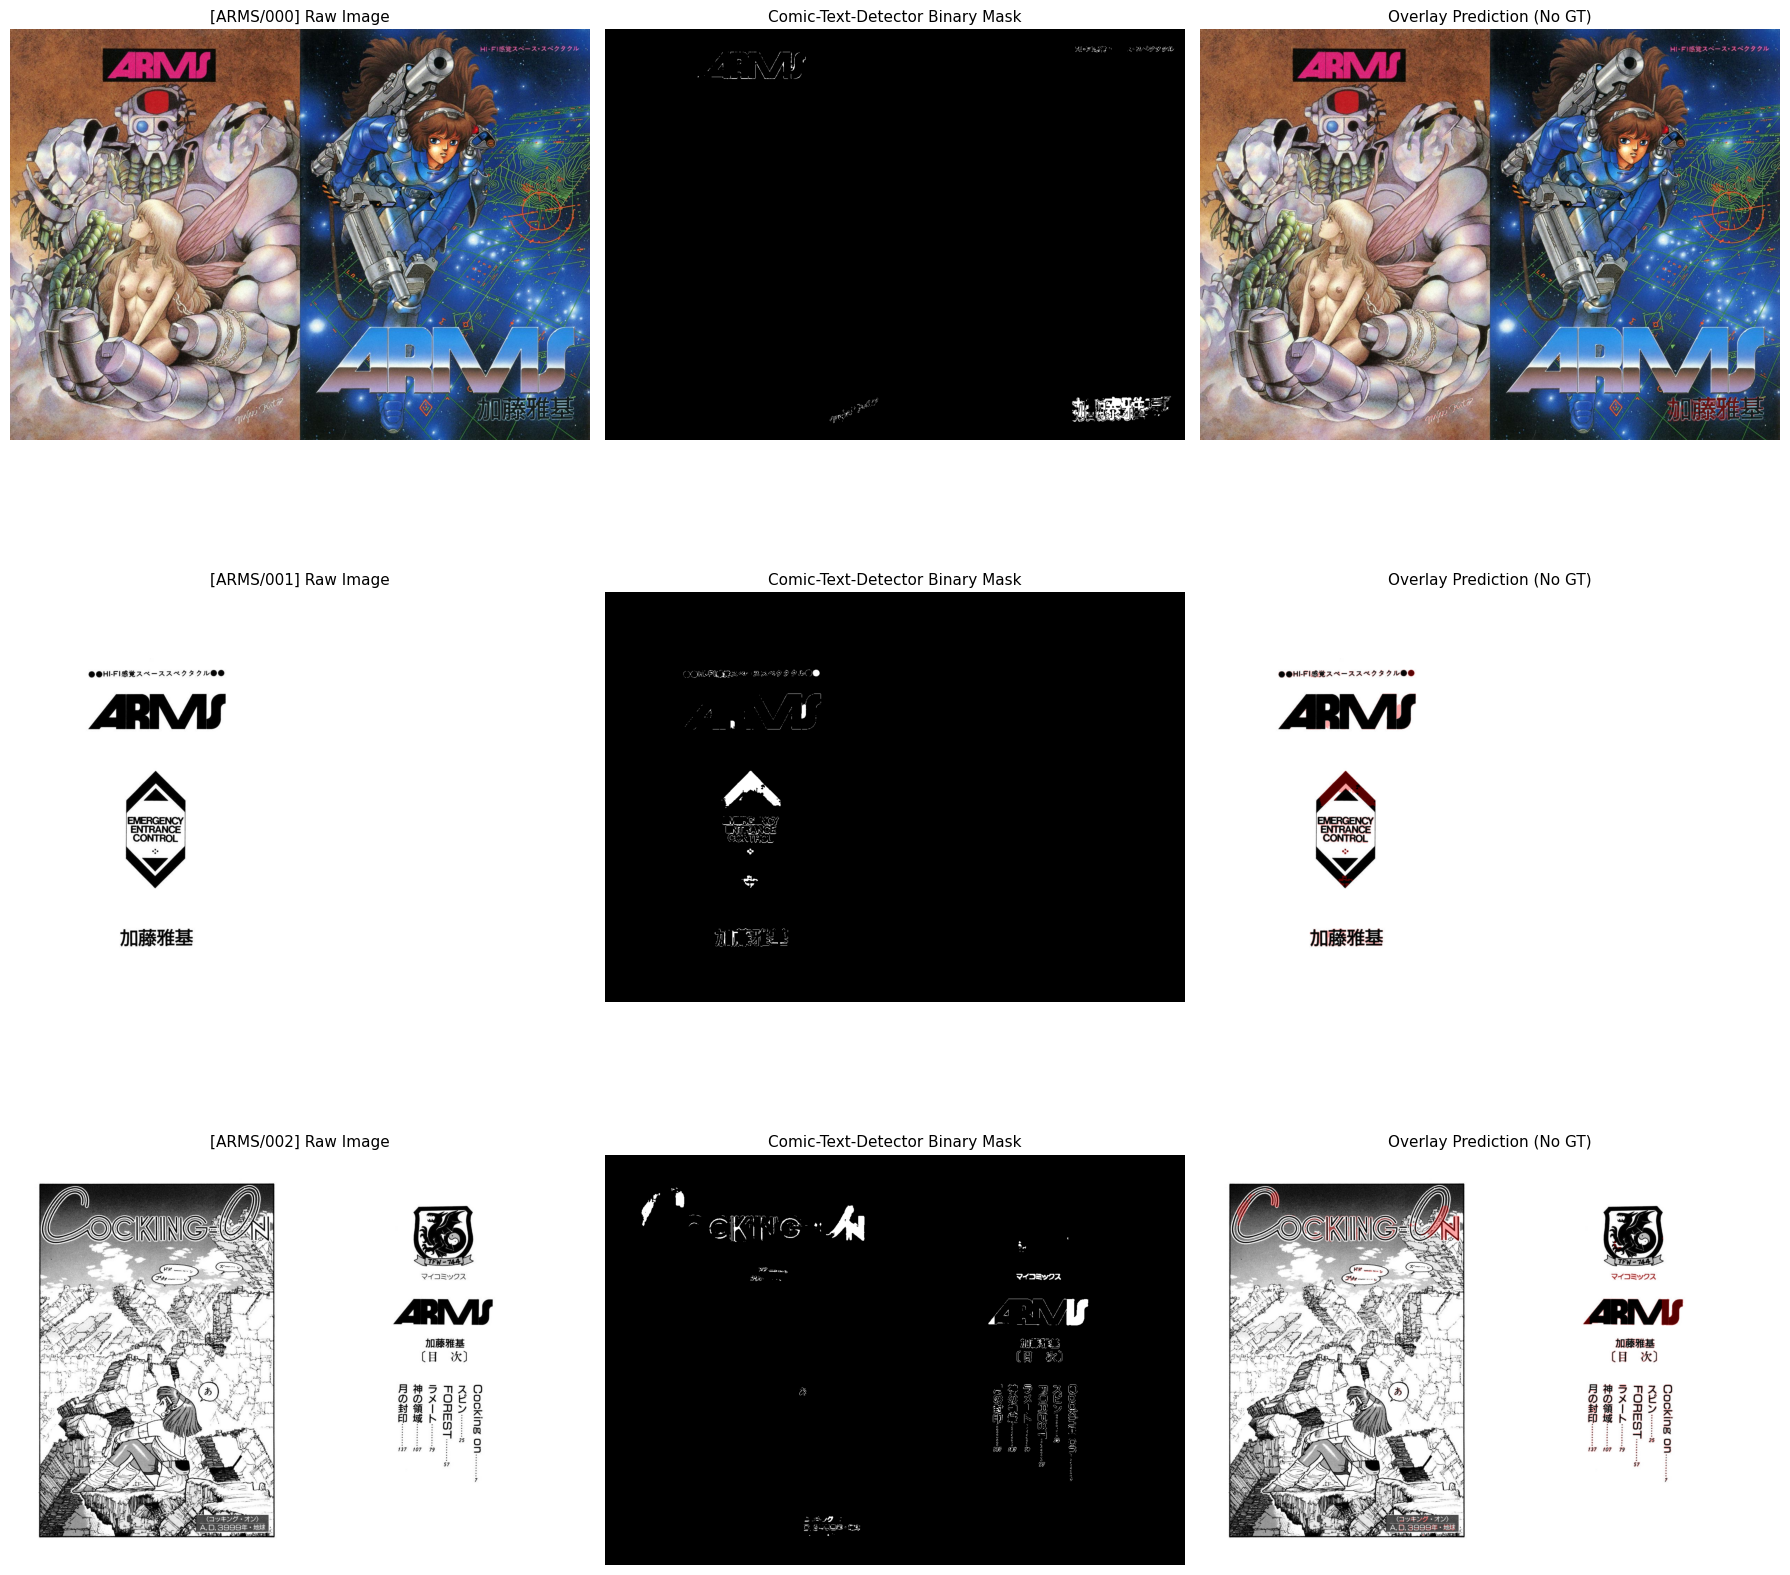

✅ Đã lưu trực quan hóa tại: /content/deliverables/comic-text-detector/visualizations/representative_cases.png


In [ ]:
import os
import cv2
import json
import shutil
import matplotlib.pyplot as plt

OUTPUT_DIR = "/content/deliverables/comic-text-detector"
os.makedirs(f"{OUTPUT_DIR}/visualizations", exist_ok=True)

# 1. Trích xuất mẫu trực quan hóa từ các trang thực tế đã tạo
vis_samples = []
masks_root = f"{OUTPUT_DIR}/masks"

for manga_name in sorted(os.listdir(masks_root)):
    manga_mask_dir = os.path.join(masks_root, manga_name)
    if os.path.isdir(manga_mask_dir):
        for f in sorted(os.listdir(manga_mask_dir)):
            if f.endswith(".png"):
                page_id = os.path.splitext(f)[0]
                raw_jpg = os.path.join(RAW_IMAGES_ROOT, manga_name, f"{page_id}.jpg")
                raw_png = os.path.join(RAW_IMAGES_ROOT, manga_name, f"{page_id}.png")
                raw_path = raw_jpg if os.path.exists(raw_jpg) else (raw_png if os.path.exists(raw_png) else None)
                mask_path = os.path.join(manga_mask_dir, f)

                if raw_path and os.path.exists(mask_path):
                    vis_samples.append({
                        "manga": manga_name,
                        "page_id": page_id,
                        "raw_path": raw_path,
                        "mask_path": mask_path
                    })
            if len(vis_samples) >= 3:
                break
    if len(vis_samples) >= 3:
        break

assert len(vis_samples) > 0, "Không tìm thấy trang nào để trực quan hóa!"

fig, axes = plt.subplots(len(vis_samples), 3, figsize=(18, 6 * len(vis_samples)))
if len(vis_samples) == 1:
    axes = [axes]

for row_idx, item in enumerate(vis_samples):
    manga = item["manga"]
    page = item["page_id"]

    raw_img = cv2.imread(item["raw_path"])
    pred_mask = cv2.imread(item["mask_path"], cv2.IMREAD_GRAYSCALE)

    if pred_mask.shape[:2] != raw_img.shape[:2]:
        pred_mask = cv2.resize(pred_mask, (raw_img.shape[1], raw_img.shape[0]), interpolation=cv2.INTER_NEAREST)

    overlay = raw_img.copy()
    overlay[pred_mask == 255] = [0, 0, 255]
    pred_overlay = cv2.addWeighted(raw_img, 0.65, overlay, 0.35, 0)

    # Panel 1: Raw Image
    axes[row_idx][0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    axes[row_idx][0].set_title(f"[{manga}/{page}] Raw Image", fontsize=11)
    axes[row_idx][0].axis('off')

    # Panel 2: Prediction Mask
    axes[row_idx][1].imshow(pred_mask, cmap='gray', vmin=0, vmax=255)
    axes[row_idx][1].set_title("Comic-Text-Detector Binary Mask", fontsize=11)
    axes[row_idx][1].axis('off')

    # Panel 3: Overlay Prediction lên Raw (Không có Ground-Truth)
    axes[row_idx][2].imshow(cv2.cvtColor(pred_overlay, cv2.COLOR_BGR2RGB))
    axes[row_idx][2].set_title("Overlay Prediction (No GT)", fontsize=11)
    axes[row_idx][2].axis('off')

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/visualizations/representative_cases.png", dpi=200, bbox_inches='tight')
plt.show()
print(f"✅ Đã lưu trực quan hóa tại: {OUTPUT_DIR}/visualizations/representative_cases.png")


n_errors = len(json.load(open(f"{OUTPUT_DIR}/errors.json")))
# 2. Xuất file requirements.txt
!pip freeze > {OUTPUT_DIR}/requirements.txt

# 3. Xuất file README.md chuẩn hợp đồng Spec 002 & ONBOARDING
readme_content = f"""# Deliverable: comic-text-detector (Method B)

## Model & Provenance
- **Kiến trúc:** Pipeline tích hợp YOLOv5s backbone, U-Net segmentation head và DBNet text-line detection.
- **Repository:** https://github.com/Ajatt-Tools/comic_text_detector
- **Commit:** {commit_hash}
- **Code License:** GPL-3.0
- **Checkpoint:** `comictextdetector.pt`
  - Source: https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt
  - Dung lượng: {model_size} bytes (~76.25 MB)
  - SHA256: {checkpoint_sha256}
  - Weight License: GPL-3.0
  - Evidence: File size và SHA256 checksum được kiểm tra runtime hợp lệ trước khi suy luận.

## Giới hạn Contamination (Spec 002)
Tập dữ liệu huấn luyện công bố của `comic-text-detector` có trích xuất từ Manga109-s nhưng không công bố phân chia train/val/test cụ thể. Theo quy định Spec 002, runner KHÔNG tự ý loại bỏ trang hoặc can thiệp dữ liệu (chạy đủ 390 trang). Điểm số và mức độ contamination sẽ do project chính công bố đối chứng theo tiêu chí SC-011.

## Đánh giá & Metrics
- **Quy định FR-057:** Runner **KHÔNG TÍNH VÀ KHÔNG NỘP METRICS** (`metrics_per_page.csv`, `metrics_summary.json`). Toàn bộ metrics (IoU, Precision, Recall, F1) sẽ do quy trình đánh giá dùng chung của project chính tính toán tập trung từ các prediction mask bàn giao.
- **Tổng số trang xử lý thành công:** {actual_count}/390 trang ({n_errors} trang lỗi).\n
- **Thiết bị suy luận:** {device_name} (loại: {device_type}).
- **Thời gian suy luận per-page:** Được ghi nhận chi tiết tại từng sidecar JSON (gồm `inference_time_seconds`, `preprocessing_time_seconds`, `postprocessing_time_seconds`).

## Preprocessing & Output Convention
- **Tiền xử lý:** Letterbox về kích thước 1024x1024 với stride-64 bottom-right zero-padding, scale 1/255.
- **Binarization:** Sigmoid threshold 0.235 (ngưỡng nội bộ của mô hình).
- **Lựa chọn đầu ra:** Chỉ trích xuất pixel segmentation mask (`ret[0]`), loại bỏ text line boxes.
- **Aligned Space:** Resize nearest-neighbor về kích thước chuẩn 1654 x 1170 (Width x Height).
- **Mask Format:** PNG single-channel, uint8, background = 0, text = 255.
- **Metadata Sidecar:** Mỗi mask có một file JSON sidecar đi kèm ghi đầy đủ 2 trường sống còn: `page_list_identity` và `input_image_identity` (SHA256 của ảnh đầu vào).
- **Visualization:** Chỉ bàn giao ảnh gốc, prediction mask và overlay prediction lên ảnh gốc (không nộp ground-truth hay overlay GT).

## Cấu trúc Deliverables
```text
deliverables/comic-text-detector/
├── README.md
├── requirements.txt
├── errors.json                 # Rỗng [] — không có trang lỗi
├── masks/                      # {actual_count} masks PNG 1654x1170 {{0, 255}}
│   └── <manga>/<page_id>.png
├── metadata/                   # {actual_count} metadata JSON sidecar
│   └── <manga>/<page_id>.json
└── visualizations/             # Ảnh minh họa không dùng GT
    ├── representative_cases.png
    └── <manga>/<page_id>_overlay.png
```
"""

In [ ]:
with open(f"{OUTPUT_DIR}/README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)
print(f"✅ Đã tạo file: {OUTPUT_DIR}/README.md")

# 5. Đóng gói deliverables thành file ZIP
zip_path = "/content/comic_text_detector_deliverables"
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)
print(f"✅ Đã nén thành công deliverables: {zip_path}.zip")

# 6. Sao lưu bản hoàn chỉnh vào Drive
drive_zip = f"{DATASET_DIR}/comic_text_detector_deliverables.zip" # Define drive_zip
shutil.copyfile(f"{zip_path}.zip", drive_zip)
print(f"✅ Đã sao lưu an toàn vào Google Drive: {drive_zip}")

✅ Đã tạo file: /content/deliverables/comic-text-detector/README.md
✅ Đã nén thành công deliverables: /content/comic_text_detector_deliverables.zip
✅ Đã sao lưu an toàn vào Google Drive: /content/drive/MyDrive/DIP/comic_text_detector_deliverables.zip
